2.21.0
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


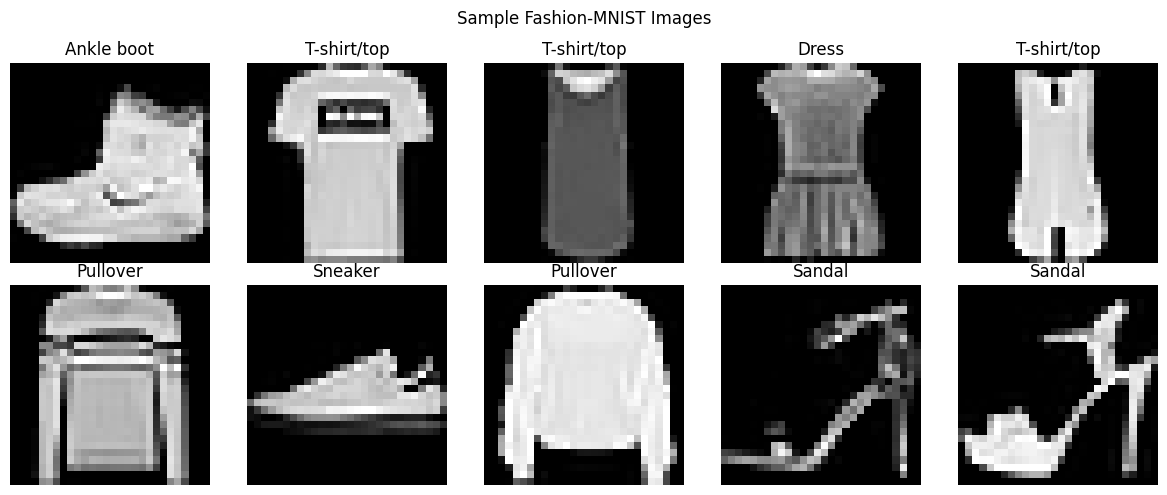

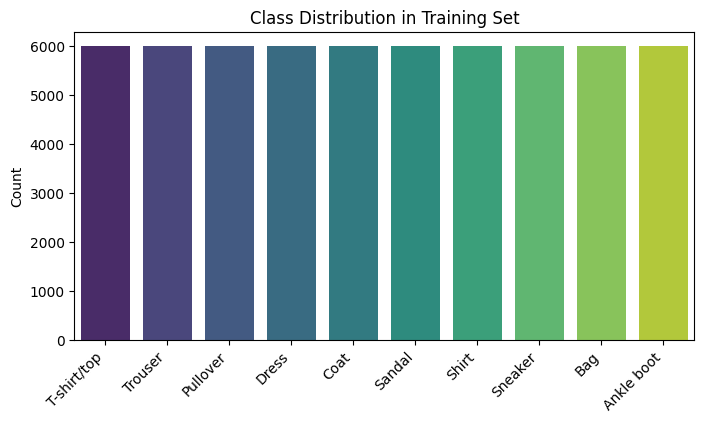

(60000, 784) (60000, 10)
(10000, 784) (10000, 10)


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_82 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8139 - loss: 0.5318 - val_accuracy: 0.8435 - val_loss: 0.4249
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8636 - loss: 0.3811 - val_accuracy: 0.8505 - val_loss: 0.4249
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8725 - loss: 0.3471 - val_accuracy: 0.8630 - val_loss: 0.3755
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8837 - loss: 0.3203 - val_accuracy: 0.8807 - val_loss: 0.3302
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8887 - loss: 0.3019 - val_accuracy: 0.8767 - val_loss: 0.3412
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8951 - loss: 0.2865 - val_accuracy: 0.8828 - val_loss: 0.3219
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8980 - loss: 0.2742 - val_accuracy: 0.8740 - val_loss: 0.3511
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9016 - loss: 0.2648 - val_accuracy: 0.

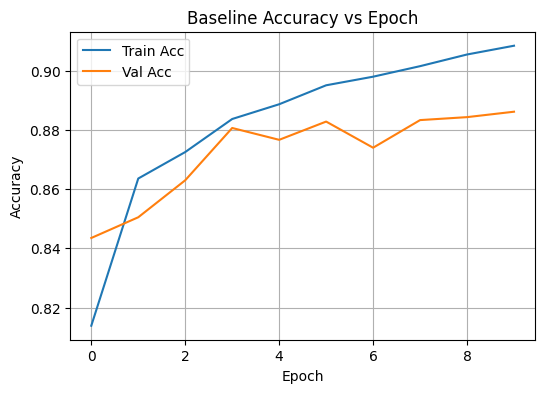

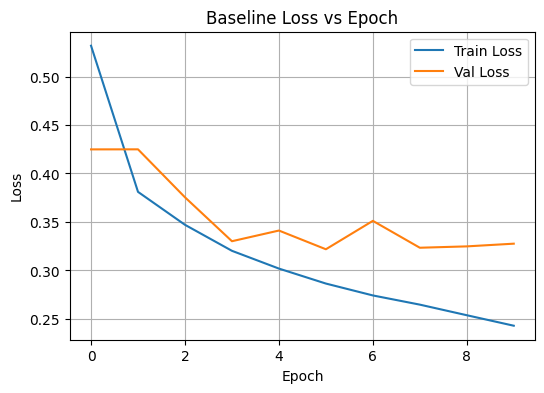

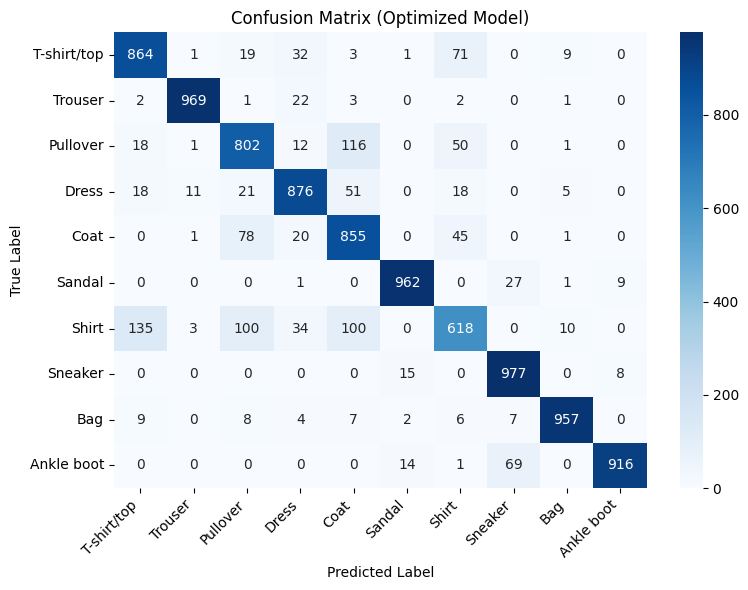

   param_model__hidden_layers  param_model__hidden_neurons  \
4                           1                           64   
1                           2                           64   
5                           2                           64   
0                           1                          128   
2                           1                           64   

  param_model__optimizer param_model__activation  mean_test_score  
4                   adam                    relu         0.881367  
1                   adam                    relu         0.857067  
5                   adam                    relu         0.832033  
0                    sgd                    relu         0.806783  
2                    sgd                    relu         0.781133  


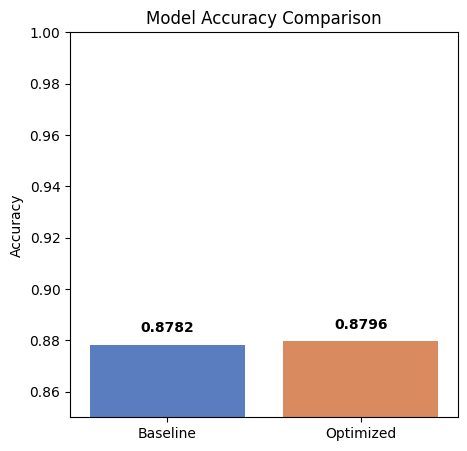

In [2]:
# Experiment 2 - MLP for Image Classification (Fashion-MNIST)
# Name: [Your Name]
# Roll No: [Your Roll No]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
import time
import warnings
warnings.filterwarnings('ignore')  # scikeras throws a bunch of noisy warnings, ignoring them

print(tf.__version__)

# loading fashion-mnist
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

# quick look at some samples
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle('Sample Fashion-MNIST Images')
plt.tight_layout()
plt.show()

# class balance check
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
sns.barplot(x=[class_names[i] for i in unique], y=counts, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Class Distribution in Training Set')
plt.ylabel('Count')
plt.show()
# 6000 per class - dataset is balanced, no need for class weights

# flatten 28x28 images into 784-length vectors for the MLP
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

x_train_norm = x_train_flat / 255.0
x_test_norm = x_test_flat / 255.0

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print(x_train_norm.shape, y_train_cat.shape)
print(x_test_norm.shape, y_test_cat.shape)

# baseline model, nothing fancy - 2 hidden layers
baseline_model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
baseline_model.summary()

start_time = time.time()
baseline_history = baseline_model.fit(
    x_train_norm, y_train_cat,
    epochs=10, batch_size=64,
    validation_split=0.1, verbose=1
)
baseline_time = time.time() - start_time
print(f"baseline training took {baseline_time:.1f}s")

y_pred_prob = baseline_model.predict(x_test_norm)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1:", f1_score(y_test, y_pred, average='weighted'))
print(classification_report(y_test, y_pred, target_names=class_names))

def build_model(hidden_layers=2, hidden_neurons=128, learning_rate=0.01,
                optimizer='adam', activation='relu', dropout_rate=0.0):
    model = Sequential()
    model.add(Dense(hidden_neurons, activation=activation, input_shape=(784,)))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    for _ in range(hidden_layers - 1):
        model.add(Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation='softmax'))

    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

keras_classifier = KerasClassifier(model=build_model, verbose=0)

# scikeras wants the "model__" prefix for anything going into build_model
# keeping this grid small on purpose - a full grid here would take forever on CPU
param_dist = {
    "model__hidden_layers": [1, 2],
    "model__hidden_neurons": [64, 128],
    "model__learning_rate": [0.01, 0.001],
    "model__optimizer": ['adam', 'sgd'],
    "model__activation": ['relu'],
    "model__dropout_rate": [0.0, 0.2],
    "batch_size": [32, 64],
    "epochs": [8, 12]
}

# 6 combos x 3 folds = 18 fits, should take a few minutes instead of a full grid search
random_search = RandomizedSearchCV(
    estimator=keras_classifier,
    param_distributions=param_dist,
    n_iter=6, cv=3,
    scoring='accuracy', random_state=42, n_jobs=1,
    verbose=2   # prints progress for each fit, otherwise it looks frozen
)

random_search.fit(x_train_norm, y_train_cat)

print("Best params:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))

# best_estimator_ is already refit on the full training set, so just use it directly
best_estimator = random_search.best_estimator_
y_pred_opt_prob = best_estimator.predict(x_test_norm)
y_pred_opt = np.argmax(y_pred_opt_prob, axis=1)

print("Optimized test accuracy:", accuracy_score(y_test, y_pred_opt))

# accuracy/loss curves for the baseline
plt.figure(figsize=(6, 4))
plt.plot(baseline_history.history['accuracy'], label='Train Acc')
plt.plot(baseline_history.history['val_accuracy'], label='Val Acc')
plt.title('Baseline Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(baseline_history.history['loss'], label='Train Loss')
plt.plot(baseline_history.history['val_loss'], label='Val Loss')
plt.title('Baseline Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# confusion matrix for the tuned model
cm = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Optimized Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# top 5 configs from the search
search_results = pd.DataFrame(random_search.cv_results_)
top_results = search_results.sort_values(by='rank_test_score').head(5)
print(top_results[['param_model__hidden_layers', 'param_model__hidden_neurons',
                    'param_model__optimizer', 'param_model__activation', 'mean_test_score']])

# baseline vs optimized accuracy
plt.figure(figsize=(5, 5))
models = ['Baseline', 'Optimized']
accs = [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_opt)]
sns.barplot(x=models, y=accs, palette='muted')
plt.ylim(0.85, 1.0)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for i, v in enumerate(accs):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()